In [1]:
import json

PATH_TO_CONSTANTS = "../"
with open(PATH_TO_CONSTANTS+'constants.json') as f:
    CONSTANTS = json.load(f)

In [2]:
with open(f"{PATH_TO_CONSTANTS}{CONSTANTS['llm_outs']}/prompt_testing/0_1000.json") as f:
    prompts = json.load(f)

In [3]:
import re


for k,v  in prompts.items():

    matches = re.findall(r"\{.*?\}", v['text'], re.DOTALL)

    if matches:
        last_json_str = matches[-1]  # Get the last JSON block
        try:
            parsed_json = json.loads(last_json_str, strict = False)  # Parse JSON
            if 'question' not in parsed_json or 'answer' not in parsed_json:
                print(k, parsed_json.keys())
                prompts[k]['json'] = "ERROR"

            else:
                prompts[k]['json'] = parsed_json
        except json.JSONDecodeError as e:
            print(k,e)
            prompts[k]['json'] = "ERROR"
            
    else:
        prompts[k]['json'] = "ERROR"
        print("No JSON found in the output.")
        
    #230 

572 Expecting property name enclosed in double quotes: line 1 column 2 (char 1)
642 Expecting property name enclosed in double quotes: line 1 column 2 (char 1)
788 Expecting property name enclosed in double quotes: line 1 column 2 (char 1)
1285 Unterminated string starting at: line 3 column 13 (char 316)
1298 Expecting property name enclosed in double quotes: line 1 column 2 (char 1)
1572 Expecting property name enclosed in double quotes: line 1 column 2 (char 1)
1642 Expecting property name enclosed in double quotes: line 1 column 2 (char 1)
1768 Expecting property name enclosed in double quotes: line 1 column 2 (char 1)
1957 Unterminated string starting at: line 3 column 13 (char 262)
2448 Expecting ',' delimiter: line 4 column 3 (char 532)
2572 Expecting property name enclosed in double quotes: line 1 column 2 (char 1)
2642 Unterminated string starting at: line 4 column 13 (char 568)
2890 Expecting ',' delimiter: line 4 column 1 (char 364)
3557 Unterminated string starting at: line 

In [4]:
#Manual features:
# quesiton length
# answer length
# json parseable -> high penalty
# answer with line breaks


In [5]:
# print(prompts['804']['text'])

In [6]:
prompts['0']

{'prompt_id': '0',
 'id': 0,
 'graphlet_id': 7,
 'text': 'Here is a generated biomedical question-answer pair in JSON format, incorporating multiple hops from the provided graphlet to enhance complexity:\n\n```\n{\n  "question": "A patient undergoing treatment with Botulinum toxin for neuromuscular blockade may be at increased risk of enhanced neuromuscular blockade effects if also administered which of the following, which itself is also known to interact with Botulinum toxin?",\n  "answer": "Tobramycin or Magnesium chloride, as both have been associated with neuromuscular blockade and have interactions with Botulinum toxin, potentially exacerbating its effects."\n}\n```\n\n**Rationale for the QA pair:**\n\n- **Starting Point (Node 1: Botulinum_toxin)**: The question begins with Botulinum toxin, a known cause of neuromuscular blockade (Node 0), to establish a clinical context.\n  \n- **First Hop (Edge [1, 0])**: The question directly references the relationship between Botulinum toxin

In [7]:
text_lengths = {}
question_lengths = {}
answer_lengths = {}

for entry in prompts.values():
    prompt_id = entry['prompt_id']
    text_length = len(entry['text'])
    
    if prompt_id not in text_lengths:
        text_lengths[prompt_id] = []
        question_lengths[prompt_id] = []
        answer_lengths[prompt_id] = []

    
    text_lengths[prompt_id].append(text_length)
    if entry['json'] != 'ERROR':
        question_lengths[prompt_id].append(len(entry['json']['question']))
        answer_lengths[prompt_id].append(len(entry['json']['answer']))

# Compute averages
average_text_length = {pid: sum(lengths) / len(lengths) for pid, lengths in text_lengths.items()}
average_q_length = {pid: sum(lengths) / len(lengths) for pid, lengths in question_lengths.items()}
average_a_length = {pid: sum(lengths) / len(lengths) for pid, lengths in answer_lengths.items()}



print(average_text_length)

{'0': 1869.141, '1': 1957.448, '2': 2205.017, '3': 2174.174, '4': 2530.806, '5': 2201.348, '6': 2177.725, '7': 2520.056, '8': 2279.387, '9': 2390.578, '10': 2383.213, '11': 3588.12, '12': 2961.614, '13': 2712.692, '14': 3398.24}


In [8]:
average_q_length


{'0': 336.76629889669005,
 '1': 256.03923541247485,
 '2': 375.718875502008,
 '3': 293.7703109327984,
 '4': 348.9127382146439,
 '5': 284.4182547642929,
 '6': 245.24924623115578,
 '7': 326.63967611336034,
 '8': 273.4616161616162,
 '9': 265.1111111111111,
 '10': 262.96188565697094,
 '11': 315.3131313131313,
 '12': 292.85513078470825,
 '13': 285.84236947791163,
 '14': 230.85542168674698}

In [9]:
error_counter = {}
for entry in prompts.values():
    prompt_id = entry['prompt_id']
    text_length = len(entry['text'])
    if prompt_id not in error_counter: 
        error_counter[prompt_id] = 0
    if entry['json'] == "ERROR":
        error_counter[prompt_id] += 1



print(error_counter)

{'0': 3, '1': 6, '2': 4, '3': 3, '4': 3, '5': 3, '6': 5, '7': 12, '8': 10, '9': 10, '10': 3, '11': 10, '12': 6, '13': 4, '14': 4}


In [10]:
# _id = 15

# print(prompts[str(600+_id)]['json']['question'])
# print(prompts[str(600+_id)]['json']['answer'])
# print()
# print(prompts[str(500+_id)]['json']['question'])
# print(prompts[str(500+_id)]['json']['answer'])
# print()

# print(prompts[str(1400+_id)]['json']['question'])
# print(prompts[str(1400+_id)]['json']['answer'])


In [11]:
average_text_length

{'0': 1869.141,
 '1': 1957.448,
 '2': 2205.017,
 '3': 2174.174,
 '4': 2530.806,
 '5': 2201.348,
 '6': 2177.725,
 '7': 2520.056,
 '8': 2279.387,
 '9': 2390.578,
 '10': 2383.213,
 '11': 3588.12,
 '12': 2961.614,
 '13': 2712.692,
 '14': 3398.24}

In [12]:
# question_lengths =[]
# answer_lengths=[]
# for k,v in prompts.items():
#     if v['json'] != "ERROR":
#         try:
#             question_lengths.append(len(v['json']['question']))
#             answer_lengths.append(len(v['json']['answer']))
#             if len(v['json']['question']) > 600:
#                 print(v['json']['question'])
#         except:
#             print(k, v['json'].keys())


In [13]:
import matplotlib.pyplot as plt

In [14]:
# plt.figure(figsize=(12, 6))

# # Plot for questions
# plt.subplot(1, 2, 1)
# plt.hist(question_lengths, bins=30, edgecolor='black', alpha=0.7)
# plt.xlabel('Length of Question')
# plt.ylabel('Frequency')
# plt.title('Distribution of Question Lengths')

# # Plot for answers
# plt.subplot(1, 2, 2)
# plt.hist(answer_lengths, bins=30, edgecolor='black', alpha=0.7)
# plt.xlabel('Length of Answer')
# plt.ylabel('Frequency')
# plt.title('Distribution of Answer Lengths')

# # Display the plots
# plt.tight_layout()
# plt.show()

In [15]:
feature_extraction_prompts = {}

counter = 0 

answer_node_in_question= """I will give you a question and answer pair, your job is to tell me if the answer is present within the question. The answer should have a specific entity not mentioned in the question, if this does not happen return true. Similarly if the answer is a yes/no question or a description about the entities present in the question return true. Please respond only with JSON:\n{"justification": justification, "answer_node_in_question": true/false}.\nThe justification should be a single string, and "answer_node_in_question" must only be a boolean."""

question_mentions_graphlet_terms = """I will give you a question, your job is to tell me if the question mentions any terms that could be related to a graphlet. Please respond only with JSON: \n {"justification": justification, "question_mentions_graphlet_terms: true/false}.\nThe justification should be a single string, and "question_mentions_graphlet_terms" must only be a boolean."""

answer_mentions_graphlet_terms = """I will give you an answer to a question, your job is to tell me if the answer mentions any terms that could be related to a graphlet. Please respond only with JSON: \n {"justification": justification, "answer_mentions_graphlet_terms: true/false}.\nThe justification should be a single string, and "answer_mentions_graphlet_terms" must only be a boolean."""

scientifically_accurate_question = """I will give you a question, your job is to tell me if the question is scientifically accurate and makes sense from a biological standpoint. The question should sound like an expert is asking it. Further the question should not be trivial. Please respond only with JSON:\n{"justification": justification, "scientifically_accurate_question": true/false}.\nThe justification should be a single string, and "scientifically_accurate_question" must only be a boolean."""

scientifically_accurate_answer = """I will give you an answer to a question, your job is to tell me if the answer is scientifically accurate and makes sense from a biological standpoint. The answer should not be one worded, and be a relatively complete answer, explaining justifications. Please respond only with JSON:\n{"justification": justification, "scientifically_accurate_answer": true/false}.\nThe justification should be a single string, and "scientifically_accurate_answer" must only be a boolean."""

answers_question = """I will give you a question/answer pair, your job is to tell me if the answer correctly answers the question, and the answer is complete, not lacking in any additional knowledge. Please respond only with JSON: \n {"justification": justification, "answers_question": true/false}.\nThe justification should be a single string, and "answers_question" must only be a boolean."""


for k,items in prompts.items():
    if items['json'] != "ERROR":
        q = items['json']['question']
        a = items['json']['answer']
        

        
        feature_extraction_prompts[k]={
            "id": items['id'],
            "prompt_id": items['prompt_id'],
            "graphlet_id": items['graphlet_id'],
            "answer_node_in_question": answer_node_in_question+f"\nQuestion: {q}\nAnswer: {a}",
            "question_mentions_graphlet_terms": question_mentions_graphlet_terms+f"\nQuestion: {q}\nAnswer: {a}",
            "answer_mentions_graphlet_terms": answer_mentions_graphlet_terms+f"\nQuestion: {q}\nAnswer: {a}",
            "scientifically_accurate_question": scientifically_accurate_question+f"\nQuestion: {q}\nAnswer: {a}",
            "scientifically_accurate_answer": scientifically_accurate_answer+f"\nQuestion: {q}\nAnswer: {a}",
            "answers_question": answers_question+f"\nQuestion: {q}\nAnswer: {a}"
            }
        #evaluate if the answer node is present in the question: 
        

In [16]:
print(answer_mentions_graphlet_terms
      )

I will give you an answer to a question, your job is to tell me if the answer mentions any terms that could be related to a graphlet. Please respond only with JSON: 
 {"justification": justification, "answer_mentions_graphlet_terms: true/false}.
The justification should be a single string, and "answer_mentions_graphlet_terms" must only be a boolean.


In [17]:
feature_extraction_prompts['1400']

{'id': 400,
 'prompt_id': '1',
 'graphlet_id': 25,
 'answer_node_in_question': 'I will give you a question and answer pair, your job is to tell me if the answer is present within the question. The answer should have a specific entity not mentioned in the question, if this does not happen return true. Similarly if the answer is a yes/no question or a description about the entities present in the question return true. Please respond only with JSON:\n{"justification": justification, "answer_node_in_question": true/false}.\nThe justification should be a single string, and "answer_node_in_question" must only be a boolean.\nQuestion: What is the potential therapeutic application of Propenidazole, considering its relationships with other entities, and how might this impact a patient undergoing treatment with Ribostamycin?\nAnswer: Propenidazole is connected to Neosaxitoxin and Letibotulinumtoxina, both of which are linked to neuromuscular blockade. Given Ribostamycin\'s association with neuro

In [39]:
with open(f'{PATH_TO_CONSTANTS}{CONSTANTS['llm_outs']}/prompt_eval/prompts_1000.json', 'w') as fp:
    json.dump(feature_extraction_prompts, fp)

In [23]:
feature_extraction_prompts['0'].keys()

dict_keys(['answer_node_in_question', 'question_mentions_graphlet_terms', 'answer_mentions_graphlet_terms', 'scientificall_accurate_question', 'scientificall_accurate_answer', 'answers_question'])

In [18]:
with open(f"{PATH_TO_CONSTANTS}{CONSTANTS['llm_outs']}/prompt_eval/prompt_evaluation_qa_nemotron_new_prompts.json") as f:
    outputs = json.load(f)

In [19]:
len(outputs.keys())

89484

In [20]:
print(outputs['4'])

{'text': '```\n{\n  "justification": "This answer is partially scientifically accurate. Botulinum toxin works by inhibiting the release of acetylcholine at the neuromuscular junction, leading to muscle paralysis. Tobramycin, an aminoglycoside antibiotic, can indeed enhance neuromuscular blockade effects when used concurrently with neuromuscular blocking agents, including potentially Botulinum toxin, due to its ability to reduce acetylcholine release and interfere with calcium ion entry at the nerve terminal. However, its direct interaction with Botulinum toxin\'s specific mechanism is more indirect compared to its general neuromuscular blocking enhancement. On the other hand, Magnesium chloride can potentiate neuromuscular blockade by reducing acetylcholine release and decreasing the sensitivity of the postsynaptic membrane to acetylcholine, but there\'s limited direct evidence of a specific interaction with Botulinum toxin that would exacerbate its effects beyond general neuromuscular

In [21]:
import re
merged_data = {}

errors =  0 

for k,v  in outputs.items():

    matches = re.findall(r"\{(?:[^{}]|\{[^{}]*\})*\}", v['text'], re.DOTALL)

    if matches:
        last_json_str = matches[-1].lower().replace("\n", " ").replace("'", "")  # Get the last JSON block
        # last_json_str = r"{}".format(last_json_str)  # Get the last JSON block
        
        try:
            parsed_json = json.loads((last_json_str), strict = False)  # Parse JSON
            if v['type'] not in list(parsed_json.keys()) or (v['type'] in parsed_json.keys() and type(parsed_json[v['type']]) != bool):
                
                print(k,v['type'], list(parsed_json.keys())[-1])
                merged_data[k] = {v['type']:"ERROR"}      
                errors+=1          
            else:
                
                merged_data[k] = parsed_json
        except json.JSONDecodeError as e:
            # print(k,e, last_json_str)
            merged_data[k]=  {v['type']:"ERROR"}      
            errors+=1          

            
    else:
        errors+=1          
        merged_data[k] = {v['type']:"ERROR"}      

        print("No JSON found in the output.")
        
    #230 

No JSON found in the output.
No JSON found in the output.


In [22]:
errors


623

In [23]:
outputs['22']

{'text': '```\n{\n  "justification": "The provided answer is incorrect for several reasons. Firstly, prolyl-tRNA synthetase 2, mitochondrial, is not a known enzyme directly linked to Non-specific early-onset epileptic encephalopathy or the other mentioned conditions in a manner that fits the described multi-step relationship. The enzyme associated with Spinocerebellar Ataxia Type 17 (SCA17) is actually TBP (TATA-binding protein), which is involved in transcription regulation, not prolyl-tRNA synthetase 2. While rigidity is a symptom that can overlap across various neurological conditions, the specific enzyme connection provided does not accurately reflect current scientific understanding. Rigidity in Hereditary late-onset Parkinson\'s disease and Non-specific early-onset epileptic encephalopathy, as well as in SCA17, is not directly linked through prolyl-tRNA synthetase 2, mitochondrial, as suggested.",\n  "scientifically_accurate_answer": false\n}\n```',
 'type': 'scientifically_accur

In [24]:
def flatten_and_group(d, group_size=6):
    grouped_dict = {}
    keys = list(d.keys())

    for i in range(0, len(keys), group_size):
        group_key = str(i // group_size)  # Group index as key
        merged_entry = {}

        for j in range(i, min(i + group_size, len(keys))):
            entry = d[keys[j]]
            stack = [(entry, merged_entry)]

            while stack:
                current, flat = stack.pop()
                for k, v in current.items():
                    if isinstance(v, dict):
                        stack.append((v, flat))  # Merge nested dicts
                    else:
                        flat[k] = v  # Add non-dict values directly
        
        grouped_dict[group_key] = merged_entry
    
    return grouped_dict

grouped_dict = flatten_and_group(merged_data)

# Print formatted output
# print(json.dumps(grouped_dict, indent=2))

In [25]:
prompts['0']['json']

{'question': 'A patient undergoing treatment with Botulinum toxin for neuromuscular blockade may be at increased risk of enhanced neuromuscular blockade effects if also administered which of the following, which itself is also known to interact with Botulinum toxin?',
 'answer': 'Tobramycin or Magnesium chloride, as both have been associated with neuromuscular blockade and have interactions with Botulinum toxin, potentially exacerbating its effects.'}

In [26]:
grouped_dict['0']

{'justification': 'the answer correctly identifies two substances (tobramycin and magnesium chloride) that can enhance neuromuscular blockade effects when combined with botulinum toxin, providing specific examples that address the question. however, the answers completeness could be improved by mentioning the nature of the interactions (e.g., aminoglycoside antibiotics like tobramycin can potentiate neuromuscular blockade, and magnesium chloride can enhance neuromuscular transmission blockade) for a deeper understanding.',
 'answer_node_in_question': False,
 'question_mentions_graphlet_terms': False,
 'answer_mentions_graphlet_terms': False,
 'scientifically_accurate_question': True,
 'scientifically_accurate_answer': False,
 'answers_question': True}

In [27]:
answer_node_in_question_values = [ i['answer_node_in_question'] for i in grouped_dict.values() if i['answer_node_in_question'] != "ERROR"]
question_mentions_graphlet_terms_values = [ i['question_mentions_graphlet_terms'] for i in grouped_dict.values() if i['question_mentions_graphlet_terms'] != "ERROR"]
answer_mentions_graphlet_terms_values = [ i['answer_mentions_graphlet_terms'] for i in grouped_dict.values() if i['answer_mentions_graphlet_terms'] != "ERROR"]
scientifically_accurate_question_values = [ i['scientifically_accurate_question'] for i in grouped_dict.values() if i['scientifically_accurate_question'] != "ERROR"]
scientifically_accurate_answer_values = [ i['scientifically_accurate_answer'] for i in grouped_dict.values() if i['scientifically_accurate_answer'] != "ERROR"]
answers_question_values = [ i['answers_question'] for i in grouped_dict.values() if i['answers_question'] != "ERROR"]

In [28]:
print("answer_node_in_question_values: ", sum(answer_node_in_question_values), len(answer_node_in_question_values))
print("question_mentions_graphlet_terms_values: ", sum(question_mentions_graphlet_terms_values), len(question_mentions_graphlet_terms_values))
print("answer_mentions_graphlet_terms_values: ", sum(answer_mentions_graphlet_terms_values), len(answer_mentions_graphlet_terms_values))
print("scientifically_accurate_question_values: ", sum(scientifically_accurate_question_values), len(scientifically_accurate_question_values))
print("scientifically_accurate_answer_values: ", sum(scientifically_accurate_answer_values), len(scientifically_accurate_answer_values))
print("answers_question_values: ", sum(answers_question_values), len(answers_question_values))

answer_node_in_question_values:  1199 14697
question_mentions_graphlet_terms_values:  3520 14572
answer_mentions_graphlet_terms_values:  5484 14893
scientifically_accurate_question_values:  12984 14885
scientifically_accurate_answer_values:  6861 14900
answers_question_values:  10248 14914


In [29]:
# grouped_dict
len(prompts),len(grouped_dict)



(15000, 14914)

In [67]:
# prompts_new = dict()
# for k,v in prompts.items():
#     if v['json']!="ERROR":
#         # prompts_new[k] = v
#         if v['answer_node_in_question'] == "ERROR" or v['question_mentions_graphlet_terms'] == "ERROR" \
#             or v['answer_mentions_graphlet_terms'] == "ERROR" or v['scientifically_accurate_question'] == "ERROR" or\
#                          v['scientifically_accurate_answer'] == "ERROR" or v['answers_question'] == "ERROR":
#             continue
#         else:
#             prompts_new[k] = v
# len(prompts_new), len(prompts)

In [68]:
prompts['0']

{'prompt_id': '0',
 'id': 0,
 'graphlet_id': 7,
 'text': 'Here is a generated biomedical question-answer pair in JSON format, incorporating multiple hops from the provided graphlet to enhance complexity:\n\n```\n{\n  "question": "A patient undergoing treatment with Botulinum toxin for neuromuscular blockade may be at increased risk of enhanced neuromuscular blockade effects if also administered which of the following, which itself is also known to interact with Botulinum toxin?",\n  "answer": "Tobramycin or Magnesium chloride, as both have been associated with neuromuscular blockade and have interactions with Botulinum toxin, potentially exacerbating its effects."\n}\n```\n\n**Rationale for the QA pair:**\n\n- **Starting Point (Node 1: Botulinum_toxin)**: The question begins with Botulinum toxin, a known cause of neuromuscular blockade (Node 0), to establish a clinical context.\n  \n- **First Hop (Edge [1, 0])**: The question directly references the relationship between Botulinum toxin

In [69]:

false_dict = {"answer_node_in_question": True, 
            "question_mentions_graphlet_terms": True, 
            "answer_mentions_graphlet_terms": True, 
            "scientifically_accurate_question": False,
            "scientifically_accurate_answer": False,
            "answers_question": False}

counter = 0
for k in prompts.keys():
    if prompts[k]['json'] != "ERROR":
        prompts[k].update(grouped_dict[str(counter)])
        counter +=1
    
    else:
        prompts[k].update(false_dict)

In [71]:
true_dict = {"answer_node_in_question": False, 
            "question_mentions_graphlet_terms": False, 
            "answer_mentions_graphlet_terms": False, 
            "scientifically_accurate_question": True,
            "scientifically_accurate_answer": True,
            "answers_question": True}

for k in prompts.keys():
    score = 0
    for key, bool_value in true_dict.items():
        if prompts[k][key] == bool_value:
            score+=1
    prompts[k]['score'] = score

In [72]:
scores = [i['score'] for i in prompts.values()]

In [73]:
# import matplotlib.pyplot as plt
# plt.hist(scores, bins=6, edgecolor='black')  # 'bins' specifies the number of intervals

# # Add title and labels
# plt.title('Example Histogram')
# plt.xlabel('Value')
# plt.ylabel('Frequency')

# # Show the plot
# plt.show()

In [74]:
# prompts['100']

In [75]:
grouped_scores = {}
# grouped_scores_list = {}

for entry in prompts.values():
    score = entry['score']
    group_id = entry['prompt_id']
    
    # Add score to the respective group
    if group_id not in grouped_scores:
        grouped_scores[group_id] = {'total_score': 0, 'count': 0, 'list': []}
    
    grouped_scores[group_id]['total_score'] += score
    grouped_scores[group_id]['count'] += 1
    grouped_scores[group_id]['list'].append(score)

# Calculate average score by group_id
average_scores = {group_id: round(group_data['total_score'] / group_data['count'], 2) 
                  for group_id, group_data in grouped_scores.items()}

# Print the average scores by group_id
print(average_scores)

{'0': 3.45, '1': 3.94, '2': 3.94, '3': 4.39, '4': 4.43, '5': 3.96, '6': 4.37, '7': 4.25, '8': 4.4, '9': 3.43, '10': 4.4, '11': 4.68, '12': 4.71, '13': 4.79, '14': 4.91}


In [76]:
average_scores

{'0': 3.45,
 '1': 3.94,
 '2': 3.94,
 '3': 4.39,
 '4': 4.43,
 '5': 3.96,
 '6': 4.37,
 '7': 4.25,
 '8': 4.4,
 '9': 3.43,
 '10': 4.4,
 '11': 4.68,
 '12': 4.71,
 '13': 4.79,
 '14': 4.91}

In [ ]:
{'1.1': 3.45,
 '1.2': 3.94,
 '2.1': 3.94,
 '2.2': 4.39,
 '3.1': 4.43,
 '3.2': 3.96,
 '3.3': 4.37,
 '3.4': 4.25,
 '3.5': 4.4,
 '4.1': 3.43,
 '4.2': 4.4,
 '4.3': 4.68,
 '4.4': 4.71,
 '4.5': 4.79,
 '5': 4.91}

In [77]:
id_to_label_mapping = [1.1, 1.2, 2.1, 2.2, 3.1, 3.2,3.3, 3.4, 3.5, 4.1, 4.2, 4.3, 4.4, 4.5, 5] 

/tmp/ipykernel_3913399/2310836278.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='CustomLabel', y='Score', data=df_scores, order=id_to_label_mapping, palette=label_colors)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

4.5 vs. 5: Mann-Whitney-Wilcoxon test two-sided, P_val:2.129e-01 U_stat=4.846e+05
4.4 vs. 5: Mann-Whitney-Wilcoxon test two-sided, P_val:1.944e-03 U_stat=4.617e+05
4.3 vs. 5: Mann-Whitney-Wilcoxon test two-sided, P_val:1.337e-04 U_stat=4.527e+05


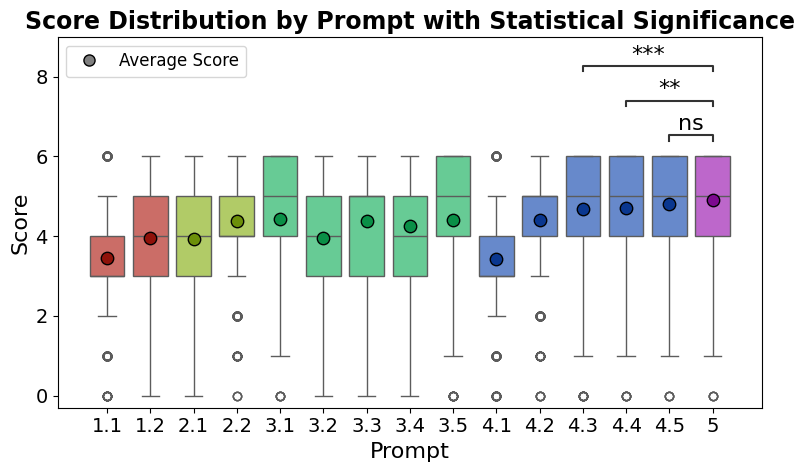

In [78]:
from statannotations.Annotator import Annotator
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Increase default font size for all elements
plt.rcParams.update({'font.size': 16})  # Increase base font size

# Creating DataFrame for individual scores for the box plot
rows = []
for prompt_id, details in grouped_scores.items():
    for score in details['list']:
        rows.append({'Prompt': prompt_id, 'Score': score})
df_scores = pd.DataFrame(rows)

# Define custom x-axis labels
id_to_label_mapping = ['1.1', '1.2', '2.1', '2.2', '3.1', '3.2', '3.3', '3.4', '3.5', '4.1', '4.2', '4.3', '4.4', '4.5', '5']

# Map each prompt to its corresponding custom label
prompt_to_label = {str(i): id_to_label_mapping[i] for i in range(len(id_to_label_mapping))}
df_scores['CustomLabel'] = df_scores['Prompt'].apply(lambda x: prompt_to_label[str(x)])

# Define the order of prompts sorted numerically
order = sorted(df_scores['Prompt'].unique(), key=lambda x: int(x))

# Create a color list for the box plot based on the first digit of each label
unique_groups = sorted(set([label.split('.')[0] for label in id_to_label_mapping]))
# Choose a better color palette - using "hls" which has distinct, vibrant colors
color_palette = sns.color_palette("hls", len(unique_groups))

# Create a mapping from each label to its color
label_colors = []
for label in id_to_label_mapping:
    group = label.split('.')[0]
    group_index = unique_groups.index(group)
    label_colors.append(color_palette[group_index])

# Set up the figure and box plot
plt.figure(figsize=(8, 5))
ax = sns.boxplot(x='CustomLabel', y='Score', data=df_scores, order=id_to_label_mapping, palette=label_colors)

# Increase font size for tick labels
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Define pairs of custom labels to compare - update these to match your actual labels
pairs = [('5', '4.5'), ('4.3', '5'),('4.4', '5')]  # Update with your desired comparisons

# Overlay the average score with markers that match the group colors
for i, label in enumerate(id_to_label_mapping):
    group = label.split('.')[0]
    group_index = unique_groups.index(group)
    color = color_palette[group_index]
    
    # Make scatter point darker than its corresponding box for better visibility
    darker_color = tuple(max(0, c-0.3) for c in color)  # Darker version of the same color
    
    avg_value = df_scores[df_scores['CustomLabel'] == label]['Score'].mean()
    plt.scatter(i, avg_value, color=darker_color, marker='o', s=80, 
                edgecolors='black', zorder=3, linewidth=1.0)

# Create an Annotator object to add statistical annotations
annotator = Annotator(ax, pairs, data=df_scores, x="CustomLabel", y="Score", order=id_to_label_mapping)

# Configure the annotator to use the Mann-Whitney test, display stars, and place annotations inside the boxes
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside', verbose=2, fontsize=16)  # Increased fontsize for stars

# Apply the annotations
annotator.apply_and_annotate()

# Customize the plot appearance with larger fonts
plt.title('Score Distribution by Prompt with Statistical Significance', fontsize=17, fontweight='bold')
plt.xlabel('Prompt', fontsize=16)
plt.ylabel('Score', fontsize=16)

# Add a legend for the average score marker with larger font
plt.plot([], [], 'o', color='black', markersize=8, markerfacecolor='gray', 
         markeredgecolor='black', label='Average Score')
plt.legend(loc='upper left', fontsize=12)

# Show the plot
plt.tight_layout()
plt.savefig(PATH_TO_CONSTANTS+CONSTANTS['figures']+"/prompt_eval.pdf", dpi=300, bbox_inches='tight')  # Higher DPI for better quality
plt.show()

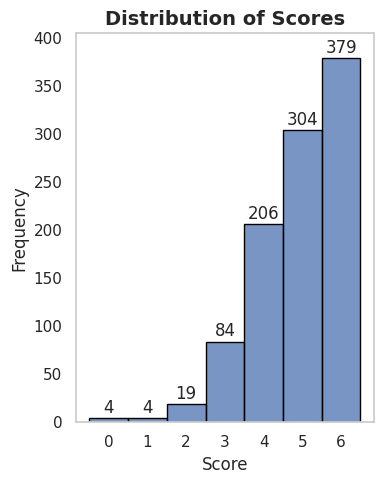

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set Seaborn style
sns.set(style="whitegrid")

# Get the data
data = grouped_scores['14']['list']

plt.figure(figsize=(4, 5))

# Create histogram and capture the bar container
ax = sns.histplot(data, bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5],
                  edgecolor='black', kde=False)

ax.grid(False)
ax.set_ylim(0, 405)



# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=1)

# Customize labels and title
plt.xlabel('Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Scores', fontsize=14, weight='bold')
plt.xticks([0,1, 2, 3, 4, 5, 6])

# Show the plot
plt.tight_layout()
plt.savefig(PATH_TO_CONSTANTS+CONSTANTS['figures']+"best_prompt.pdf", dpi=300, bbox_inches='tight')  # Higher DPI for better quality
plt.show()


In [74]:
# 12# !pip install statannotations

In [74]:
# grouped_dict['551']
# Lets analyz
# prompts = [
#     ['baseline'], #baseline 2.35
#     ['baseline', 'simple_example'], #baseline with ex - 3.38 example helps
#     #testing now qa instructions
#     ['baseline','instructions_markdown', 'question_instruction', 'answer_instruction'], #baseline qa instructions 3.42 instructions help a bit
#     ['baseline','instructions_markdown', 'question_instruction', 'answer_instruction', 'simple_example'], # + example 3.45 example helps a little
#     # testing now analysis instrcutions:
#     ['baseline', 'instructions_markdown', 'analyze_graphlet_instruction', 'final_analysis'],# 3.32, improves over the baseline but is slightly worse than qa instructions
#     #node templates
#     ['baseline', 'instructions_markdown', 'analyze_graphlet_instruction', 'node_types', 'final_analysis'], #3.95 node instructions help, new best
#     ['baseline', 'instructions_markdown', 'analyze_graphlet_instruction', 'node_types', 'simple_example','final_analysis'], # example adding the simple example helps 4.28
#     ['baseline', 'instructions_markdown', 'analyze_graphlet_instruction', 'node_types', 'question_instruction', 'answer_instruction', 'final_analysis'], #QA 3.98 insturctiosn, adding qa instructions makes it worse
#     ['baseline', 'instructions_markdown', 'analyze_graphlet_instruction', 'node_types', 'question_instruction', 'answer_instruction', 'simple_example','final_analysis'], #QA insturctiosn + answer adding example in this case makes it worse, 3.68
#     # refelction
#     ['baseline','instructions_markdown','reflection_instruction'], # worsens baskine 2.17
#     ['baseline','instructions_markdown','reflection_instruction', 'complex_example'], # + example 3.13 also slightly worse than baseline
#     ['baseline','instructions_markdown','reflection_instruction', 'question_evaluation', 'answer_evaluation'], # + qa evaluation 3.45 improves over baseline equivalent
#     ['baseline','instructions_markdown','reflection_instruction', 'question_evaluation', 'answer_evaluation', 'complex_example'], # + qa evaluation + example +3.72 up over equivalen
#     ['baseline','instructions_markdown','question_instruction', 'answer_instruction','reflection_instruction', 'question_evaluation', 'answer_evaluation', 'complex_example','final_analysis'], # + qa evaluation + example # +qa instructoins 4.12 without node tyoes 
#     #all
#     ['baseline','instructions_markdown','analyze_graphlet_instruction', 'node_types','question_instruction', 'answer_instruction','reflection_instruction', 'question_evaluation', 'answer_evaluation', 'complex_example', 'final_analysis'], 
# 4.51 pb
#    ]

{'answer_node_in_question': False,
 'question_mentions_graphlet_terms': False,
 'answer_mentions_graphlet_terms': False,
 'scientifically_accurate_question': True,
 'additional_context_needed': True,
 'suggested_questions_for_clearer_assessment': ['what is the specific context (e.g., medical use, environmental impact, historical significance)?',
  'how is chloroform being used or applied in the question?'],
 'is chloroform a known anesthetic?': True,
 'is chloroform commonly used today in medical settings?': False,
 'is chloroform safe for unsupervised use?': False,
 'does chloroform have biological effects on organisms?': True,
 'answers_question': True}

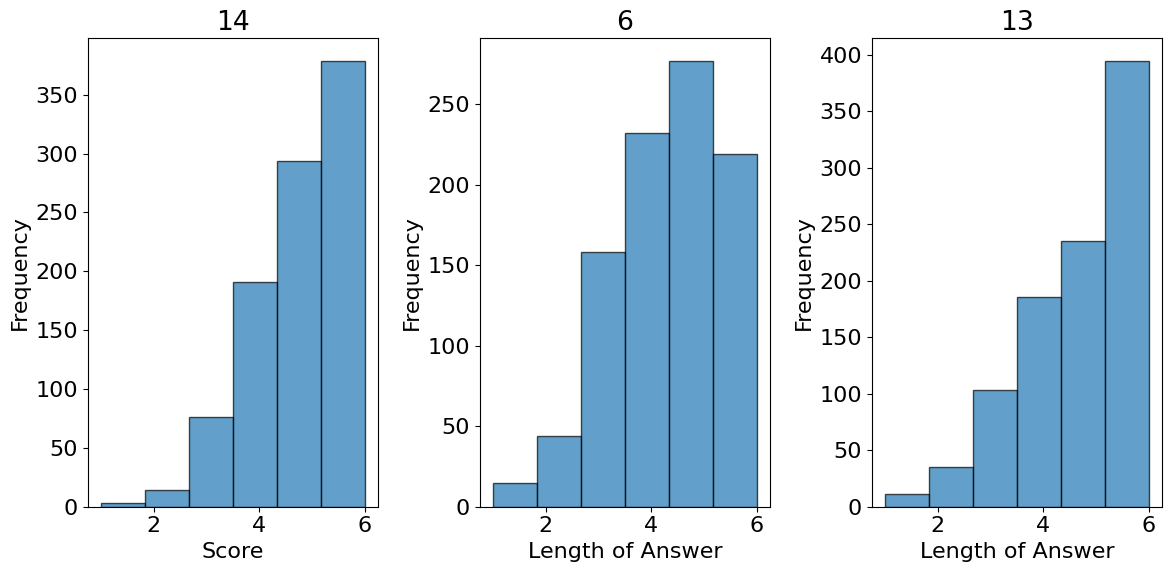

In [66]:
plt.figure(figsize=(12, 6))

# Plot for questions
plt.subplot(1, 3, 1)
plt.hist(grouped_scores['14']['list'], bins=6, edgecolor='black', alpha=0.7)
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('14')

# Plot for answers
plt.subplot(1, 3, 2)
plt.hist(grouped_scores['6']['list'], bins=6, edgecolor='black', alpha=0.7)
plt.xlabel('Length of Answer')
plt.ylabel('Frequency')
plt.title('6')

# Plot for answers
plt.subplot(1, 3, 3)
plt.hist(grouped_scores['13']['list'], bins=6, edgecolor='black', alpha=0.7)
plt.xlabel('Length of Answer')
plt.ylabel('Frequency')
plt.title('13')


# Display the plots
plt.tight_layout()
plt.show()

In [65]:
grouped_scores.keys()

dict_keys(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14'])

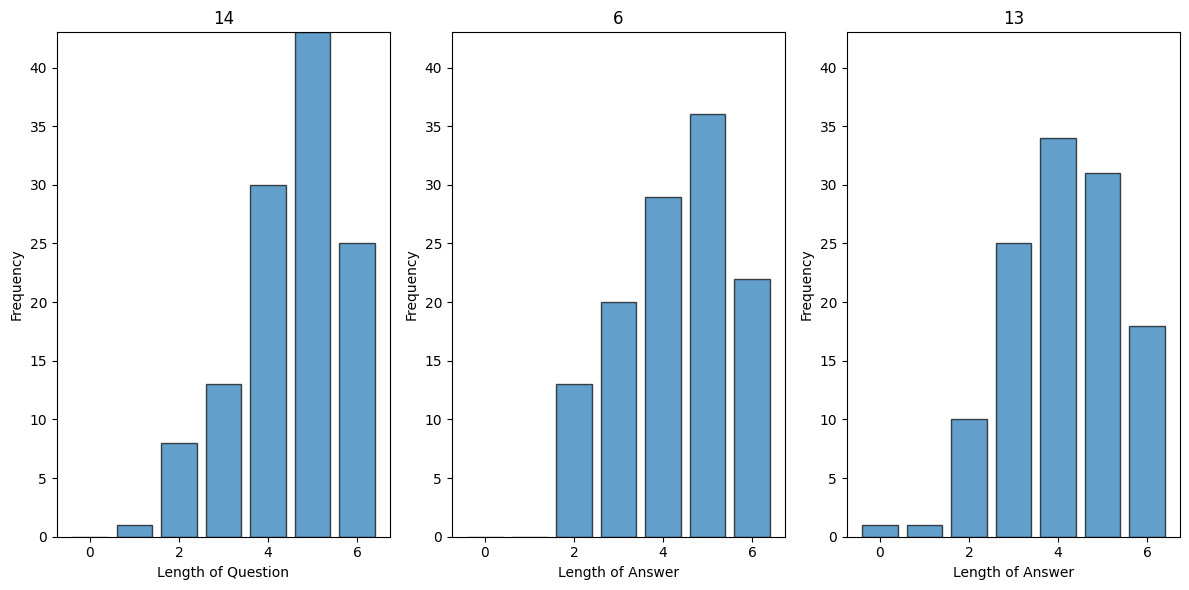

In [133]:
import numpy as np
import matplotlib.pyplot as plt

# Define the unique values (0, 1, 2, 3, 4, 5, 6)
values = [0, 1, 2, 3, 4, 5, 6]

# Calculate the global Y-axis limit based on the max frequency (now considering 0 as well)
max_y = max(
    np.histogram(grouped_scores['14']['list'], bins=np.arange(-0.5, 7.5, 1))[0].max(),
    np.histogram(grouped_scores['6']['list'], bins=np.arange(-0.5, 7.5, 1))[0].max(),
    np.histogram(grouped_scores['13']['list'], bins=np.arange(-0.5, 7.5, 1))[0].max()
)

plt.figure(figsize=(12, 6))

# Plot for question 14 (Bar plot)
plt.subplot(1, 3, 1)
hist_14 = np.histogram(grouped_scores['14']['list'], bins=np.arange(-0.5, 7.5, 1))[0]
plt.bar(values, hist_14, edgecolor='black', alpha=0.7)
plt.xlabel('Length of Question')
plt.ylabel('Frequency')
plt.title('14')
plt.ylim(0, max_y)  # Set the same Y-axis range

# Plot for question 6 (Bar plot)
plt.subplot(1, 3, 2)
hist_6 = np.histogram(grouped_scores['6']['list'], bins=np.arange(-0.5, 7.5, 1))[0]
plt.bar(values, hist_6, edgecolor='black', alpha=0.7)
plt.xlabel('Length of Answer')
plt.ylabel('Frequency')
plt.title('6')
plt.ylim(0, max_y)  # Set the same Y-axis range

# Plot for question 13 (Bar plot)
plt.subplot(1, 3, 3)
hist_13 = np.histogram(grouped_scores['13']['list'], bins=np.arange(-0.5, 7.5, 1))[0]
plt.bar(values, hist_13, edgecolor='black', alpha=0.7)
plt.xlabel('Length of Answer')
plt.ylabel('Frequency')
plt.title('13')
plt.ylim(0, max_y)  # Set the same Y-axis range

# Display the plots
plt.tight_layout()
plt.show()


In [139]:
grouped_scores['14']['count']

120

In [156]:
_ids = [14, 6]
length = 120
#
sampled_indexes = [14 ,109 ,30, 2 ,65 ,102 ,58 ,74 ,114, 119]

for _id in _ids:
    for index in sampled_indexes:
        tmp = prompts[str(_id*length + index)]
        print(f"Nodes:\n {tmp['nodes']}Edges: \n{tmp['edges']}\nQA: {tmp['json']} \nScore: {tmp['score']}\n --------------")
    print("==============================")

Nodes:
  - Adenosine_deaminase: 0 
 - Lipegfilgrastim: 1 
 - Propylene_glycol: 2 
Edges: 
- (0, 1)
- (1, 2)
- (2, 0)

QA: {'question': 'What excipient might be found in formulations of recombinant G-CSF analogs, like Lipegfilgrastim, which could be used in managing certain immunodeficiencies related to adenosine deaminase deficiency, and how might it influence the therapeutic agent?', 'answer': 'Propylene glycol is a common excipient in such formulations, enhancing stability and potentially affecting administration. Its presence in Lipegfilgrastim formulations is notable for patients with immunodeficiencies, including those related to adenosine deaminase deficiency, where drug tolerance and efficacy are crucial.'} 
Score: 4
 --------------
Nodes:
  - Pegvaliase: 0 
 - Peginesatide: 1 
 - Adenosine_deaminase: 2 
 - Methoxy_polyethylene_glycol-epoetin_beta: 3 
 - Nandrolone: 4 
Edges: 
- (0, 1)
- (1, 2)
- (2, 3)
- (3, 4)
- (0, 3)
- (1, 4)
- (3, 1)
- (2, 0)

QA: {'question': 'In managing 

In [154]:
prompts['0'].keys()

dict_keys(['prompt_id', 'template_id', 'text', 'nodes', 'edges', 'json', 'answer_node_in_question', 'question_mentions_graphlet_terms', 'answer_mentions_graphlet_terms', 'scientifically_accurate_question', 'scientifically_accurate_answer', 'rationale', 'limitation', 'answers_question', 'score'])